## Concatenating envi and covet to infer metacells

In [1]:
import scenvi
import scanpy as sc
import anndata as ad
import matplotlib as plt
import numpy as np
from anndata import AnnData 
import umap
import umap.umap_ as umap
from sklearn.neighbors import NearestNeighbors


In [4]:
sc_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad")
st_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/st_data.h5ad")
print(sc_ad)

AnnData object with n_obs × n_vars = 7416 × 13061
    obs: 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'cell_type', 'cell_supertype', 'cell_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'keep_genes'
    uns: 'COVET_genes', 'hvg'
    obsm: 'COVET', 'COVET_SQRT', 'UMAP_exp', 'cell_type_niche', 'envi_latent'
    layers: 'log'


In [5]:

envi_latent_sc = sc_ad.obsm['envi_latent']
covet_sqrt_sc=sc_ad.obsm['COVET_SQRT']
envi_latent_st=st_ad.obsm['envi_latent']
covet_sqrt_st=st_ad.obsm['COVET_SQRT']
print(f"sc_ad envi_latent shape: {envi_latent_sc.shape}")
print(f"Covet shape: {covet_sqrt_sc.shape}")

sc_ad envi_latent shape: (7416, 512)
Covet shape: (7416, 64, 64)


In [6]:
covet_sc_flat=covet_sqrt_sc.reshape(covet_sqrt_sc.shape[0],-1)
covet_st_flat=covet_sqrt_st.reshape(covet_sqrt_st.shape[0],-1)
covet=np.concatenate([covet_sc_flat,covet_st_flat])
print(covet.shape)

(25932, 4096)


In [7]:
envi=np.concatenate([envi_latent_sc,envi_latent_st])
print(envi.shape)

(25932, 512)


In [8]:
combine=np.concatenate([envi, covet],axis=1)
print(combine.shape)

(25932, 4608)


In [16]:
from sklearn.decomposition import PCA

n_components = 200
pca = PCA(n_components=n_components)

# Apply PCA
reduced_combined = pca.fit_transform(combine)

print("Reduced shape:", reduced_combined.shape)
reduced_covet=pca.fit_transform(covet)
print("covet=", reduced_covet.shape)
reduced_envi=pca.fit_transform(envi)
print("envi=", reduced_envi.shape)


Reduced shape: (25932, 200)
covet= (25932, 200)
envi= (25932, 200)


### Computing knn indices

In [17]:
from tqdm import tqdm
def compute_knn_indices(data, n_neighbors):
    n_samples = data.shape[0]
    nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(data)
    knn_indices = np.zeros((n_samples, n_neighbors), dtype=int)

    for i in tqdm(range(n_samples), desc="Computing kNN", ncols=80):
        _, indices = nbrs.kneighbors(data[i].reshape(1, -1))
        knn_indices[i] = indices[0]
        
    return knn_indices, nbrs

In [18]:
knn_indices_covet, _ = compute_knn_indices(reduced_covet, n_neighbors=5)


Computing kNN: 100%|█████████████████████| 25932/25932 [01:40<00:00, 257.71it/s]


In [19]:
knn_indices_covet

array([[    0,  5192,  5562,   446,  2184],
       [    1,  7011,  2101,  4103,  3363],
       [    2,   523,  4440,  1737,  2805],
       ...,
       [25929, 16267, 13381, 10611, 21957],
       [25930, 10395, 15192, 10168, 19891],
       [25931,  8887, 25850, 19268, 14117]])

In [21]:
knn_indices_envi, _ =compute_knn_indices(reduced_envi, n_neighbors=5)

Computing kNN: 100%|█████████████████████| 25932/25932 [01:49<00:00, 237.33it/s]


In [22]:
knn_indices_envi

array([[    0,  3091,  6692,  6303,   805],
       [    1,  7011,  6796,   346,  3016],
       [    2,  4440,  4090,  7345,  5024],
       ...,
       [25929,  7832,  9233, 16111, 18694],
       [25930, 18605, 14278, 15838,   992],
       [25931, 23511, 13914, 22855, 19312]])

### Computing individual snn matrix for covet and envi

In [24]:
import numpy as np
from tqdm import tqdm

def snn_matrix(indices: np.ndarray, n_neighbors: int) -> np.ndarray:
    n_samples = indices.shape[0]
    snn = np.zeros((n_samples, n_samples), dtype=np.float32)

    for i in tqdm(range(n_samples), desc="Calculating SNN", ncols=80):
        for j in range(i + 1, n_samples):
            nni = indices[i]
            nnj = indices[j]

            # Efficient intersection using sets
            shared = set(nni) & set(nnj)

            if shared:
                s = [
                    n_neighbors - 0.5 * (np.where(nni == k)[0][0] + np.where(nnj == k)[0][0])
                    for k in shared
                ]
                snn[i, j] = max(s)
            else:
                snn[i, j] = 0

            snn[j, i] = snn[i, j]

    return snn


In [26]:
snn_covet = snn_matrix(knn_indices_covet, n_neighbors=5)


Calculating SNN: 100%|████████████████████| 25932/25932 [08:51<00:00, 48.79it/s]


In [27]:
snn_covet

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [28]:
np.count_nonzero(snn_covet)

439848

In [29]:
snn_envi = snn_matrix(knn_indices_envi, n_neighbors=5)

Calculating SNN: 100%|████████████████████| 25932/25932 [08:53<00:00, 48.60it/s]


In [30]:
snn_envi

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [31]:
print(np.count_nonzero(snn_envi))

1760730


In [32]:
def calculate_final_snn(snn, snn_e):
    mask = (snn == 0) | (snn_e == 0)
    snn = snn.astype(float)
    snn_e = snn_e.astype(float)
    snn[mask] = np.nan
    snn_e[mask] = np.nan
    final_snn = np.nanmean(np.stack((snn, snn_e), axis=0), axis=0)
    final_snn[np.isnan(final_snn)] = 0
    return final_snn

In [33]:
final_snn=calculate_final_snn(snn_envi, snn_covet)

/var/folders/d4/bgr0tr5d43z2xmtq5hk3s4n00000gn/T/ipykernel_29794/1619995206.py:7: RuntimeWarning: Mean of empty slice
  final_snn = np.nanmean(np.stack((snn, snn_e), axis=0), axis=0)


In [58]:
import numpy as np

np.save('final_snn.npy', final_snn)
print("Saved as final_snn.npy")


Saved as final_snn.npy


In [59]:
import numpy as np
np.savetxt('/Users/anushka/Documents/Undergraduate-Project/final_snn.csv', final_snn, delimiter=',')


In [34]:
final_snn

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [35]:
np.count_nonzero(final_snn)

29408

In [36]:
adata=ad.AnnData(X=final_snn)



In [37]:
adata

AnnData object with n_obs × n_vars = 25932 × 25932

In [39]:
cell_type_palette = {'Astro': (0.843137, 0.0, 0.0, 1.0),
                     'Endo': (0.54902, 0.235294, 1.0, 1.0),
                     'L23_IT': (0.007843, 0.533333, 0.0, 1.0),
                     'L45_IT': (0.0, 0.67451, 0.780392, 1.0),
                     'L56_NP': (0.596078, 1.0, 0.0, 1.0),
                     'L5_ET': (1.0, 0.498039, 0.819608, 1.0),
                     'L5_IT': (0.423529, 0.0, 0.309804, 1.0),
                     'L5_PT': (1.0, 0.647059, 0.188235, 1.0),
                     'L6_CT': (0.345098, 0.231373, 0.0, 1.0),
                     'L6_IT': (0.0, 0.341176, 0.34902, 1.0),
                     'L6_IT_Car3': (0.0, 0.0, 0.866667, 1.0),
                     'L6b': (0.0, 0.992157, 0.811765, 1.0),
                     'Lamp5': (0.631373, 0.458824, 0.415686, 1.0),
                     'Microglia': (0.737255, 0.717647, 1.0, 1.0),
                     'OPC': (0.584314, 0.709804, 0.470588, 1.0),
                     'Oligo': (0.752941, 0.015686, 0.72549, 1.0),
                     'Pericytes': (0.392157, 0.329412, 0.454902, 1.0),
                     'Pvalb': (0.47451, 0.0, 0.0, 1.0),
                     'SMC': (0.027451, 0.454902, 0.847059, 1.0),
                     'Sncg': (0.996078, 0.960784, 0.564706, 1.0),
                     'Sst': (0.0, 0.294118, 0.0, 1.0),
                     'VLMC': (0.560784, 0.478431, 0.0, 1.0),
                     'Vip': (1.0, 0.447059, 0.4, 1.0)}

cell_label_palette = {'GABAergic': (0.843137, 0.0, 0.0, 1.0),
                      'Glutamatergic': (0.54902, 0.235294, 1.0, 1.0),
                      'Non-Neuronal': (0.007843, 0.533333, 0.0, 1.0)}

In [40]:
adata.uns["celltype_colors"] = cell_type_palette
adata.uns["cell_label_colors"] = cell_label_palette  

In [41]:
adata

AnnData object with n_obs × n_vars = 25932 × 25932
    uns: 'celltype_colors', 'cell_label_colors'

In [47]:
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)
print("Shape of combined_cell_types", combined_cell_types.shape)

Shape of combined_cell_types (25932,)


In [48]:
adata.obs["cell_type"]=combined_cell_types

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


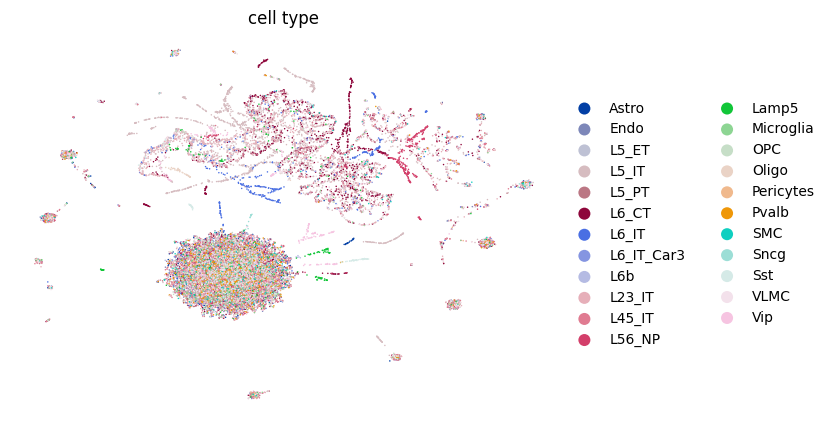

In [50]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5) 
sc.pl.scatter(adata, basis='umap',color=["cell_type"], frameon=False)


In [51]:
print("Identified Metacells:", adata.obs['leiden'].unique())

Identified Metacells: ['4', '26', '20', '35', '1', ..., '56', '51', '55', '50', '54']
Length: 58
Categories (58, object): ['0', '1', '2', '3', ..., '54', '55', '56', '57']


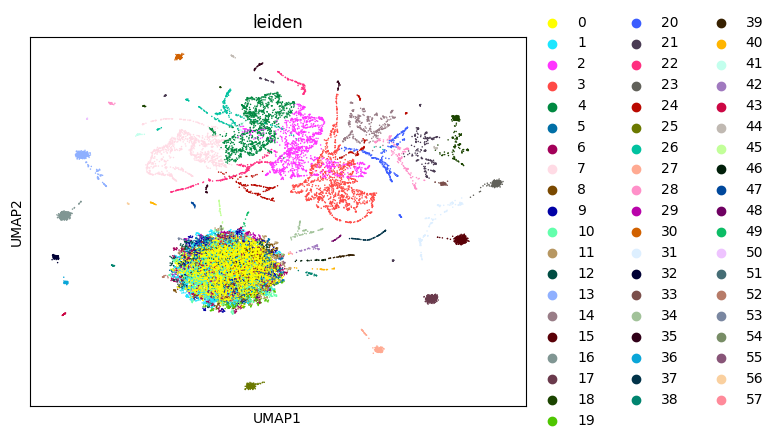

In [52]:
sc.tl.umap(adata)
sc.pl.umap(adata, color='leiden')


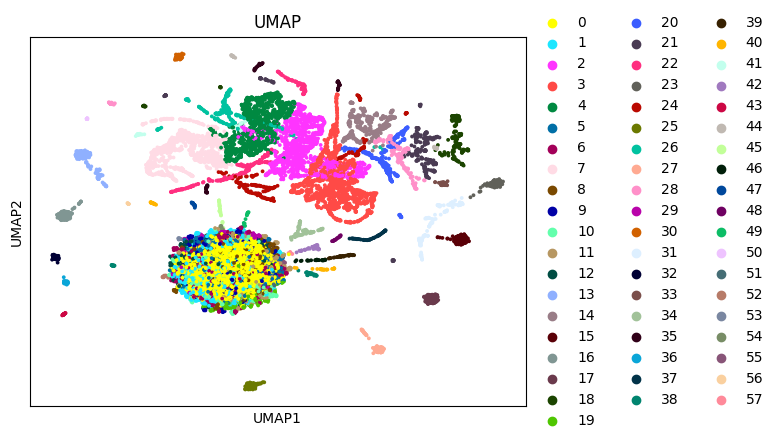

In [57]:
sc.pl.umap(adata, color='leiden', title='UMAP', size=30)
